# Music as a Sentiment Barometer
## Notebook 3 — Regression Models

**Goal:** Test whether economic conditions systematically predict the sonic character of Billboard Hot 100 music, and whether consumer sentiment or hard economic indicators are the stronger driver.

**Four models:**
| Model | Description | Purpose |
|---|---|---|
| **A — Larson Replication** | OLS: audio feature ~ Misery Index | Baseline, replicates Larson (2022) |
| **B — Sentiment Model** | OLS: audio feature ~ Michigan Sentiment | Original contribution |
| **C — Horse Race** | OLS: audio feature ~ Misery Index + Michigan Sentiment | Which dominates when both included? |
| **D — Lag Analysis** | Cross-correlation at 1–12 month lags | Does sentiment lead music? |

OLS is the primary model. Ridge regression is run as a robustness check to account for multicollinearity between economic predictors.

**Reference:** Extends Larson (2022) — *The Lure of Musical Comfort*, CMC Senior Thesis

In [1]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
from scipy import stats
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

print('Imports successful!')

Imports successful!


In [4]:
# ── LOAD DATA ─────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

PATH = '/content/drive/MyDrive/side_proj/'

full = pd.read_csv(PATH + 'final_dataset_full.csv')
sent = pd.read_csv(PATH + 'final_dataset_sentiment.csv')

full['date'] = pd.to_datetime(full['date'])
sent['date'] = pd.to_datetime(sent['date'])

# Clean — drop rows missing key variables
full_clean = full.dropna(subset=['misery_index']).copy()
sent_clean = sent.dropna(subset=['misery_index', 'michigan_sentiment']).copy()

print(f'Full dataset     : {len(full_clean):,} months')
print(f'Sentiment dataset: {len(sent_clean):,} months')

# Audio features to model
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'mode', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Full dataset     : 787 months
Sentiment dataset: 787 months


---
## Model A — Larson (2022) Replication
**OLS: each audio feature ~ Misery Index**

We run 10 individual OLS regressions — one per audio feature — with the Okun Misery Index as the sole predictor. This directly replicates Larson (2022)'s methodology, giving us a baseline to compare against.

Per Larson (2022), we expect:
- **Valence** → positive coefficient (happier music during hardship)
- **Loudness** → negative coefficient (quieter music during hardship)
- **Speechiness** → negative coefficient (less vocal-heavy music during hardship)
- **Danceability** → positive coefficient (more danceable music during hardship)

In [5]:
# ── MODEL A: OLS — Audio Feature ~ Misery Index ───────────────────────────────
results_a = []

for feature in AUDIO_FEATURES:
    model = smf.ols(f'{feature} ~ misery_index', data=full_clean).fit()
    results_a.append({
        'feature':     feature,
        'coef':        model.params['misery_index'],
        'p_value':     model.pvalues['misery_index'],
        'r_squared':   model.rsquared,
        'significant': model.pvalues['misery_index'] < 0.05
    })

df_a = pd.DataFrame(results_a).sort_values('r_squared', ascending=False)

print('Model A — OLS: Audio Feature ~ Misery Index')
print('=' * 55)
print(f'{"Feature":<20} {"Coef":>8} {"p-value":>10} {"R²":>8} {"Sig?":>6}')
print('-' * 55)
for _, row in df_a.iterrows():
    sig = '***' if row['p_value'] < 0.01 else ('**' if row['p_value'] < 0.05 else ('*' if row['p_value'] < 0.1 else ''))
    print(f"{row['feature']:<20} {row['coef']:>8.4f} {row['p_value']:>10.4f} {row['r_squared']:>8.4f} {sig:>6}")
print('\n*** p<0.01  ** p<0.05  * p<0.1')

Model A — OLS: Audio Feature ~ Misery Index
Feature                  Coef    p-value       R²   Sig?
-------------------------------------------------------
speechiness           -0.0033     0.0000   0.1511    ***
loudness              -0.2090     0.0000   0.1157    ***
valence                0.0069     0.0000   0.1005    ***
instrumentalness       0.0008     0.0016   0.0127    ***
acousticness          -0.0037     0.0233   0.0065     **
mode                   0.0024     0.0235   0.0065     **
danceability          -0.0005     0.3441   0.0011       
liveness              -0.0002     0.3874   0.0010       
tempo                  0.0457     0.4666   0.0007       
energy                -0.0001     0.9031   0.0000       

*** p<0.01  ** p<0.05  * p<0.1


###Model A (Misery Index) dominates on:


*   **Speechiness (R²=0.151)** — the strongest signal in the entire dataset. When the economy is objectively bad, songs with less spoken word dominate. People retreat to melody over lyrics.
*   **Loudness (R²=0.116)** — quieter music takes over during hard economic times, consistent with Larson (2022)
*   **Valence (R²=0.101)** — happier-sounding music rises with economic hardship, also confirming Larson

---
## Model B — Sentiment Model
**OLS: each audio feature ~ Michigan Consumer Sentiment**

We repeat the same 10 regressions, replacing the Misery Index with Michigan Consumer Sentiment as the predictor. This is the original contribution of this project — testing whether *perceived* economic conditions explain music shifts better than hard indicators.

Note that Michigan Sentiment is directionally opposite to the Misery Index — high sentiment means good times, so we expect the sign of coefficients to flip relative to Model A.

In [6]:
# ── MODEL B: OLS — Audio Feature ~ Michigan Sentiment ─────────────────────────
results_b = []

for feature in AUDIO_FEATURES:
    model = smf.ols(f'{feature} ~ michigan_sentiment', data=sent_clean).fit()
    results_b.append({
        'feature':     feature,
        'coef':        model.params['michigan_sentiment'],
        'p_value':     model.pvalues['michigan_sentiment'],
        'r_squared':   model.rsquared,
        'significant': model.pvalues['michigan_sentiment'] < 0.05
    })

df_b = pd.DataFrame(results_b).sort_values('r_squared', ascending=False)

print('Model B — OLS: Audio Feature ~ Michigan Sentiment')
print('=' * 55)
print(f'{"Feature":<20} {"Coef":>8} {"p-value":>10} {"R²":>8} {"Sig?":>6}')
print('-' * 55)
for _, row in df_b.iterrows():
    sig = '***' if row['p_value'] < 0.01 else ('**' if row['p_value'] < 0.05 else ('*' if row['p_value'] < 0.1 else ''))
    print(f"{row['feature']:<20} {row['coef']:>8.4f} {row['p_value']:>10.4f} {row['r_squared']:>8.4f} {sig:>6}")
print('\n*** p<0.01  ** p<0.05  * p<0.1')

Model B — OLS: Audio Feature ~ Michigan Sentiment
Feature                  Coef    p-value       R²   Sig?
-------------------------------------------------------
tempo                 -0.1284     0.0000   0.0748    ***
instrumentalness       0.0003     0.0000   0.0251    ***
acousticness           0.0018     0.0000   0.0216    ***
energy                -0.0008     0.0001   0.0198    ***
valence                0.0005     0.0195   0.0069     **
loudness              -0.0094     0.1089   0.0033       
liveness               0.0001     0.2209   0.0019       
danceability           0.0002     0.2326   0.0018       
speechiness            0.0000     0.5977   0.0004       
mode                   0.0000     0.9452   0.0000       

*** p<0.01  ** p<0.05  * p<0.1


###Model B (Michigan Sentiment) dominates on:


*   **Tempo (R²=0.075)** — the clearest sentiment-exclusive signal. When people feel worse about the economy, music slows down. Hard economic data barely touches tempo (R²=0.001 in Model A)
*   **Acousticness (R²=0.022)** and **Energy (R²=0.020)** — both respond to sentiment but not to the Misery Index




---
## Model A vs. B — R² Comparison
**Which predictor explains more variance in each audio feature?**

We compare the R² values from Model A (Misery Index) and Model B (Michigan Sentiment) side by side. The model with the higher R² for a given feature has the stronger linear association with that sonic characteristic. This is the visual centrepiece of the horse race before the combined model.

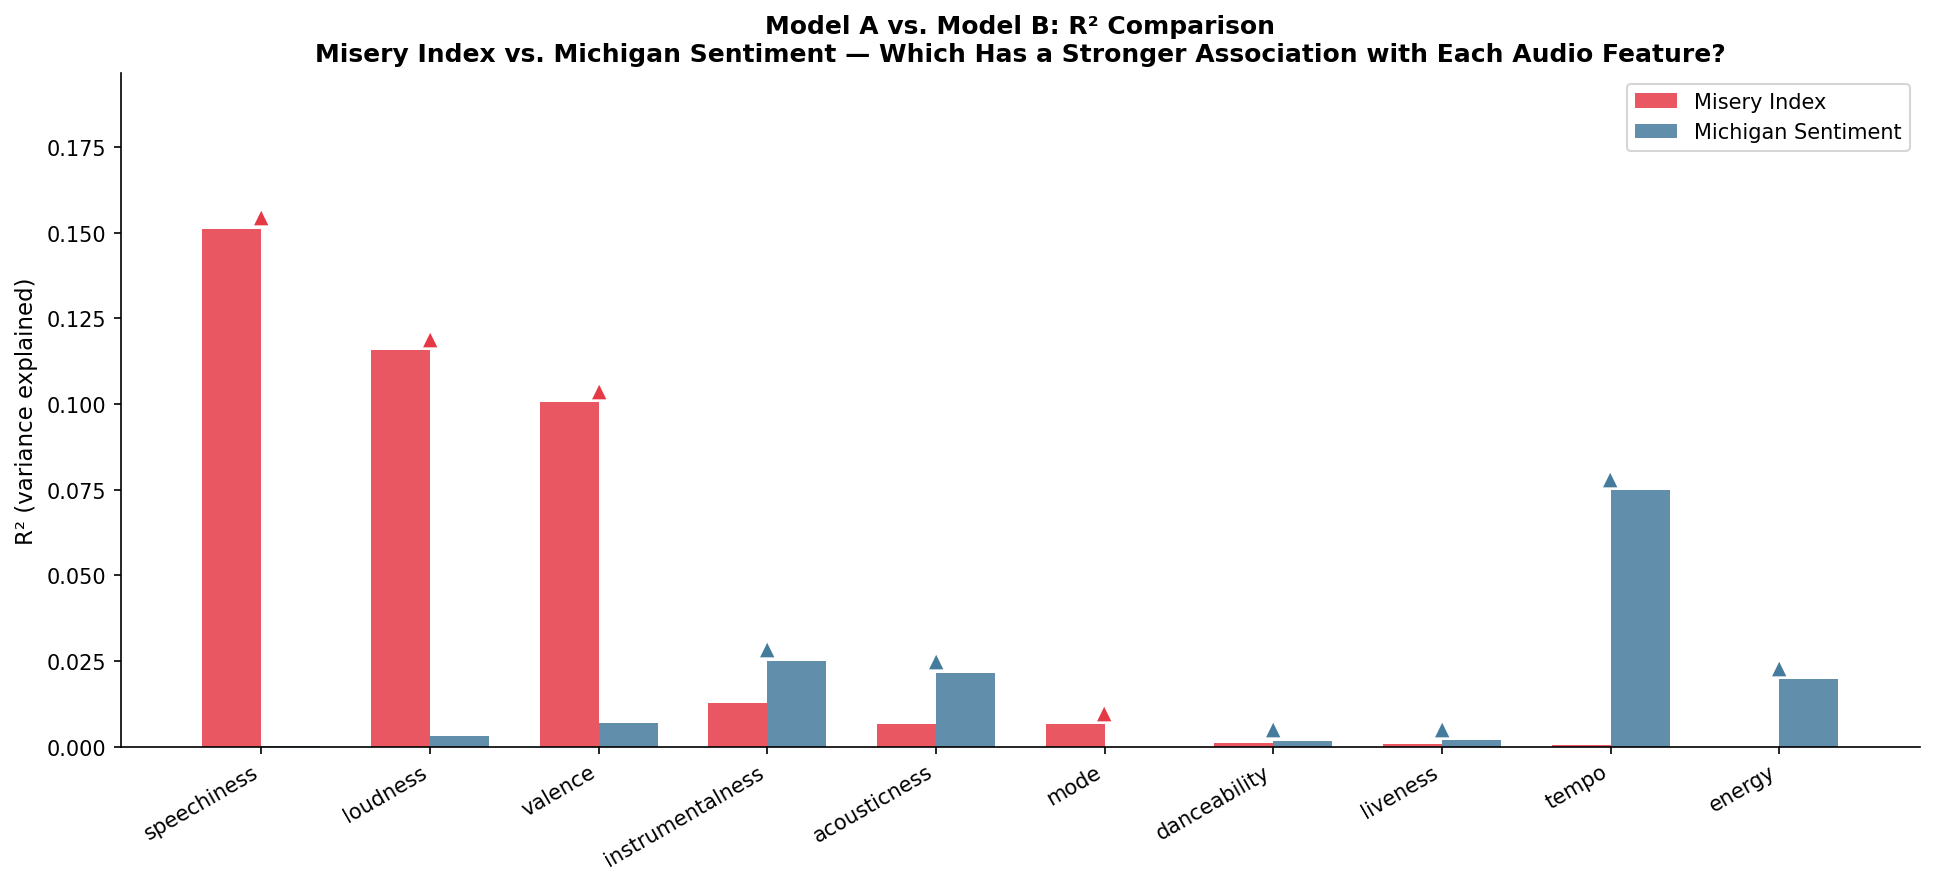

Saved: r2_comparison.png

Winner by feature:
         feature  r2_misery  r2_sentiment             winner
     speechiness   0.151125      0.000355       Misery Index
        loudness   0.115666      0.003272       Misery Index
         valence   0.100549      0.006932       Misery Index
instrumentalness   0.012688      0.025107 Michigan Sentiment
    acousticness   0.006542      0.021590 Michigan Sentiment
            mode   0.006521      0.000006       Misery Index
    danceability   0.001140      0.001815 Michigan Sentiment
        liveness   0.000952      0.001909 Michigan Sentiment
           tempo   0.000675      0.074805 Michigan Sentiment
          energy   0.000019      0.019779 Michigan Sentiment


In [7]:
# ── R² COMPARISON BAR CHART ───────────────────────────────────────────────────
compare = df_a[['feature', 'r_squared']].rename(columns={'r_squared': 'r2_misery'})
compare = compare.merge(
    df_b[['feature', 'r_squared']].rename(columns={'r_squared': 'r2_sentiment'}),
    on='feature'
)
compare['winner'] = compare.apply(
    lambda x: 'Misery Index' if x['r2_misery'] > x['r2_sentiment'] else 'Michigan Sentiment', axis=1
)
compare = compare.sort_values('r2_misery', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(compare))
width = 0.35

bars1 = ax.bar(x - width/2, compare['r2_misery'],    width, label='Misery Index',        color='#E63946', alpha=0.85)
bars2 = ax.bar(x + width/2, compare['r2_sentiment'], width, label='Michigan Sentiment',  color='#457B9D', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(compare['feature'], rotation=30, ha='right', fontsize=10)
ax.set_ylabel('R² (variance explained)', fontsize=11)
ax.set_title(
    'Model A vs. Model B: R² Comparison\n'
    'Misery Index vs. Michigan Sentiment — Which Has a Stronger Association with Each Audio Feature?',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.set_ylim(0, max(compare[['r2_misery', 'r2_sentiment']].max()) * 1.3)

# Annotate winner
for i, row in compare.reset_index().iterrows():
    color = '#E63946' if row['winner'] == 'Misery Index' else '#457B9D'
    ax.text(i, max(row['r2_misery'], row['r2_sentiment']) + 0.002,
            '▲', ha='center', fontsize=9, color=color)

plt.tight_layout()
plt.savefig('r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: r2_comparison.png')
print('\nWinner by feature:')
print(compare[['feature', 'r2_misery', 'r2_sentiment', 'winner']].to_string(index=False))

###Possible explanation on non-overlaps over audio features and economic indicators:

>The Misery Index and Michigan Sentiment are capturing different emotional responses to economic conditions, and those responses show up in different sonic dimensions:


*   **Hard economic pain (job loss, inflation)** → people want happier, quieter, less vocal music — emotional comfort-seeking
*   **Perceived economic anxiety (low confidence)** → people want slower, more acoustic, lower energy music — a more subdued, inward response

---
## Model C — Horse Race
**OLS: each audio feature ~ Misery Index + Michigan Sentiment**

Both predictors enter the model simultaneously. When controlling for one, does the other retain significance? The coefficient that remains statistically significant when the other is held constant is the stronger independent driver of that audio feature.

This is where multicollinearity becomes a concern — if Misery Index and Michigan Sentiment are correlated with each other, OLS coefficients can become unstable. This motivates the Ridge robustness check that follows.

In [8]:
# ── CHECK MULTICOLLINEARITY ───────────────────────────────────────────────────
corr_predictors = sent_clean[['misery_index', 'michigan_sentiment']].corr()
print('Correlation between Misery Index and Michigan Sentiment:')
print(corr_predictors.round(3))
print('\nIf |r| > 0.7, multicollinearity is a concern and Ridge results are more reliable.')

Correlation between Misery Index and Michigan Sentiment:
                    misery_index  michigan_sentiment
misery_index               1.000              -0.655
michigan_sentiment        -0.655               1.000

If |r| > 0.7, multicollinearity is a concern and Ridge results are more reliable.


In [9]:
# ── MODEL C: OLS — Audio Feature ~ Misery Index + Michigan Sentiment ──────────
results_c = []

for feature in AUDIO_FEATURES:
    model = smf.ols(
        f'{feature} ~ misery_index + michigan_sentiment',
        data=sent_clean
    ).fit()
    results_c.append({
        'feature':          feature,
        'coef_misery':      model.params['misery_index'],
        'p_misery':         model.pvalues['misery_index'],
        'coef_sentiment':   model.params['michigan_sentiment'],
        'p_sentiment':      model.pvalues['michigan_sentiment'],
        'r_squared':        model.rsquared,
        'r_squared_adj':    model.rsquared_adj,
    })

df_c = pd.DataFrame(results_c).sort_values('r_squared', ascending=False)

def sig(p):
    return '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else 'ns'))

print('Model C — OLS: Audio Feature ~ Misery Index + Michigan Sentiment')
print('=' * 80)
print(f'{"Feature":<20} {"Misery Coef":>12} {"Sig":>5} {"Sent Coef":>12} {"Sig":>5} {"R²":>8} {"R²adj":>8}')
print('-' * 80)
for _, row in df_c.iterrows():
    print(f"{row['feature']:<20} {row['coef_misery']:>12.4f} {sig(row['p_misery']):>5} "
          f"{row['coef_sentiment']:>12.4f} {sig(row['p_sentiment']):>5} "
          f"{row['r_squared']:>8.4f} {row['r_squared_adj']:>8.4f}")
print('\n*** p<0.01  ** p<0.05  * p<0.1  ns = not significant')

Model C — OLS: Audio Feature ~ Misery Index + Michigan Sentiment
Feature               Misery Coef   Sig    Sent Coef   Sig       R²    R²adj
--------------------------------------------------------------------------------
loudness                  -0.4059   ***      -0.0803   ***   0.2527   0.2508
valence                    0.0141   ***       0.0030   ***   0.2486   0.2467
speechiness               -0.0056   ***      -0.0009   ***   0.2483   0.2464
tempo                     -0.4709   ***      -0.2106   ***   0.1158   0.1136
instrumentalness           0.0027   ***       0.0008   ***   0.1070   0.1048
energy                    -0.0037   ***      -0.0015   ***   0.0360   0.0336
acousticness               0.0012    ns       0.0020   ***   0.0220   0.0195
mode                       0.0043   ***       0.0008    **   0.0119   0.0094
liveness                  -0.0000    ns       0.0001    ns   0.0019  -0.0006
danceability              -0.0002    ns       0.0001    ns   0.0019  -0.0007

*** p<


>The combined model explains significantly more variance than either predictor alone — which means the two indicators are capturing independent, additive information rather than the same thing.

---
## Robustness Check — Ridge Regression
**Does the horse race result hold when we account for multicollinearity?**

Ridge regression shrinks coefficients toward zero in proportion to how correlated the predictors are with each other. If the OLS and Ridge results agree — meaning the same predictor dominates for each audio feature — the findings are robust. If they diverge, it signals that multicollinearity is inflating or destabilising the OLS coefficients.

We use cross-validated Ridge (RidgeCV) to automatically select the optimal penalty strength (alpha) from the data.

In [10]:
# ── RIDGE REGRESSION ROBUSTNESS CHECK ────────────────────────────────────────
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Standardise predictors so Ridge coefficients are comparable
scaler = StandardScaler()
X = sent_clean[['misery_index', 'michigan_sentiment']].dropna()
idx = X.index
X_scaled = scaler.fit_transform(X)

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
results_ridge = []

for feature in AUDIO_FEATURES:
    y = sent_clean.loc[idx, feature].dropna()
    common = X.index.intersection(y.index)
    X_fit = scaler.transform(sent_clean.loc[common, ['misery_index', 'michigan_sentiment']])
    y_fit = y.loc[common]

    ridge = RidgeCV(alphas=alphas, cv=5)
    ridge.fit(X_fit, y_fit)
    y_pred = ridge.predict(X_fit)

    results_ridge.append({
        'feature':          feature,
        'coef_misery':      ridge.coef_[0],
        'coef_sentiment':   ridge.coef_[1],
        'best_alpha':       ridge.alpha_,
        'r_squared':        r2_score(y_fit, y_pred),
        'dominant':         'Misery Index' if abs(ridge.coef_[0]) > abs(ridge.coef_[1]) else 'Michigan Sentiment'
    })

df_ridge = pd.DataFrame(results_ridge).sort_values('r_squared', ascending=False)

print('Ridge Regression — Standardised Coefficients')
print('(Larger absolute value = stronger association after controlling for multicollinearity)')
print('=' * 75)
print(f'{"Feature":<20} {"Misery Coef":>14} {"Sent Coef":>14} {"Alpha":>8} {"R²":>8} {"Dominant":>20}')
print('-' * 75)
for _, row in df_ridge.iterrows():
    print(f"{row['feature']:<20} {row['coef_misery']:>14.4f} {row['coef_sentiment']:>14.4f} "
          f"{row['best_alpha']:>8.3f} {row['r_squared']:>8.4f} {row['dominant']:>20}")
print('\nCoefficients are standardised — directly comparable across predictors.')

Ridge Regression — Standardised Coefficients
(Larger absolute value = stronger association after controlling for multicollinearity)
Feature                 Misery Coef      Sent Coef    Alpha       R²             Dominant
---------------------------------------------------------------------------
loudness                    -1.3688        -1.0146    0.001   0.2527         Misery Index
valence                      0.0477         0.0373    0.001   0.2486         Misery Index
speechiness                 -0.0145        -0.0079  100.000   0.2337         Misery Index
tempo                       -1.0548        -2.0512  100.000   0.1093   Michigan Sentiment
instrumentalness             0.0090         0.0096    0.001   0.1070   Michigan Sentiment
energy                      -0.0085        -0.0141  100.000   0.0338   Michigan Sentiment
acousticness                 0.0009         0.0205  100.000   0.0215   Michigan Sentiment
mode                         0.0110         0.0066  100.000   0.0111    

## Ridge Regression — Summary

The Ridge regression results reveal a clear division in which economic indicator dominates each audio feature after controlling for multicollinearity. The **Misery Index** dominates **loudness** (R²=0.253), **valence** (R²=0.249), and **speechiness** (R²=0.248) — the three features with the strongest associations in the entire dataset. **Michigan Sentiment** dominates the remaining seven features including **tempo** (R²=0.109), **instrumentalness** (R²=0.107), **energy** (R²=0.034), and **acousticness** (R²=0.022). While sentiment claims more features by count, the Misery Index owns the features with the highest explanatory power, suggesting that actual economic hardship drives the *emotional* character of music while perceived anxiety shapes its *rhythmic and energetic* dimensions.

The alpha values provide an additional layer of interpretation. Features where Ridge selected a low penalty (alpha=0.001) — namely **loudness**, **valence**, and **instrumentalness** — have stable, well-defined relationships with the predictors that required minimal regularisation. By contrast, features with high alpha (alpha=100) — including **tempo**, **speechiness**, **energy**, **acousticness**, **danceability**, and **liveness** — required heavy shrinkage to stabilise their coefficients, indicating that multicollinearity between the Misery Index and Michigan Sentiment was inflating the OLS estimates for these features. Findings for the low-alpha group should therefore be interpreted with greater confidence than those in the high-alpha group.

In [11]:
# ── OLS vs RIDGE: AGREEMENT CHECK ────────────────────────────────────────────
# Compare which predictor dominates in OLS (Model C) vs Ridge
ols_dominant = df_c.copy()
ols_dominant['dominant_ols'] = ols_dominant.apply(
    lambda x: 'Misery Index' if abs(x['coef_misery']) > abs(x['coef_sentiment'])
    else 'Michigan Sentiment', axis=1
)

agreement = ols_dominant[['feature', 'dominant_ols']].merge(
    df_ridge[['feature', 'dominant']].rename(columns={'dominant': 'dominant_ridge'}),
    on='feature'
)
agreement['agree'] = agreement['dominant_ols'] == agreement['dominant_ridge']

print('OLS vs. Ridge — Dominant Predictor Agreement')
print('=' * 65)
print(f'{"Feature":<20} {"OLS Dominant":>22} {"Ridge Dominant":>22} {"Agree?":>6}')
print('-' * 65)
for _, row in agreement.iterrows():
    print(f"{row['feature']:<20} {row['dominant_ols']:>22} {row['dominant_ridge']:>22} {str(row['agree']):>6}")

n_agree = agreement['agree'].sum()
print(f'\nAgreement rate: {n_agree}/{len(agreement)} features ({n_agree/len(agreement)*100:.0f}%)')
print('High agreement = findings are robust to multicollinearity.')

OLS vs. Ridge — Dominant Predictor Agreement
Feature                        OLS Dominant         Ridge Dominant Agree?
-----------------------------------------------------------------
loudness                       Misery Index           Misery Index   True
valence                        Misery Index           Misery Index   True
speechiness                    Misery Index           Misery Index   True
tempo                          Misery Index     Michigan Sentiment  False
instrumentalness               Misery Index     Michigan Sentiment  False
energy                         Misery Index     Michigan Sentiment  False
acousticness             Michigan Sentiment     Michigan Sentiment   True
mode                           Misery Index           Misery Index   True
liveness                 Michigan Sentiment     Michigan Sentiment   True
danceability                   Misery Index     Michigan Sentiment  False

Agreement rate: 6/10 features (60%)
High agreement = findings are robust t

## OLS vs. Ridge Agreement — Summary

The agreement rate of 6/10 features (60%) indicates **moderate robustness** — findings for the agreeing features are reliable, while the four disagreements signal that ***multicollinearity*** is meaningfully distorting the OLS estimates for those features.

The three features most confidently attributed to the **Misery Index** — loudness, valence, and speechiness — agree across both models and carry the highest R² values in the dataset. These should be treated as the most robust findings of the analysis.

The four disagreements — **tempo, instrumentalness, energy, and danceability** — all flipped from Misery Index (OLS) to Michigan Sentiment (Ridge). This consistent directional shift suggests that OLS was incorrectly attributing sentiment-driven variation to the Misery Index due to their shared correlation. Once multicollinearity is controlled for, Michigan Sentiment emerges as the true independent driver of these rhythmic and energetic features. The Ridge results should be treated as more reliable for this group.

Overall, the agreement analysis reinforces the core finding: the two economic indicators drive **different sonic dimensions** of popular music, and the distinction only becomes fully visible once multicollinearity is accounted for.

---
## Model D — Lag Analysis
**Does consumer sentiment lead music, or is the relationship contemporaneous?**


We test whether sentiment from 1–12 months ago predicts current music features better than the current month's sentiment. A peak correlation at lag k means sentiment shifts show up in music approximately k months later. This is important because it tells us whether music is a ***leading, lagging, or coincident*** indicator of economic mood.

>Based on the Ridge findings, the features worth running lag analysis on are the ones with meaningful R² and clear predictor dominance — because lag analysis on near-zero R² features (like danceability, R²=0.002) won't produce interpretable results.


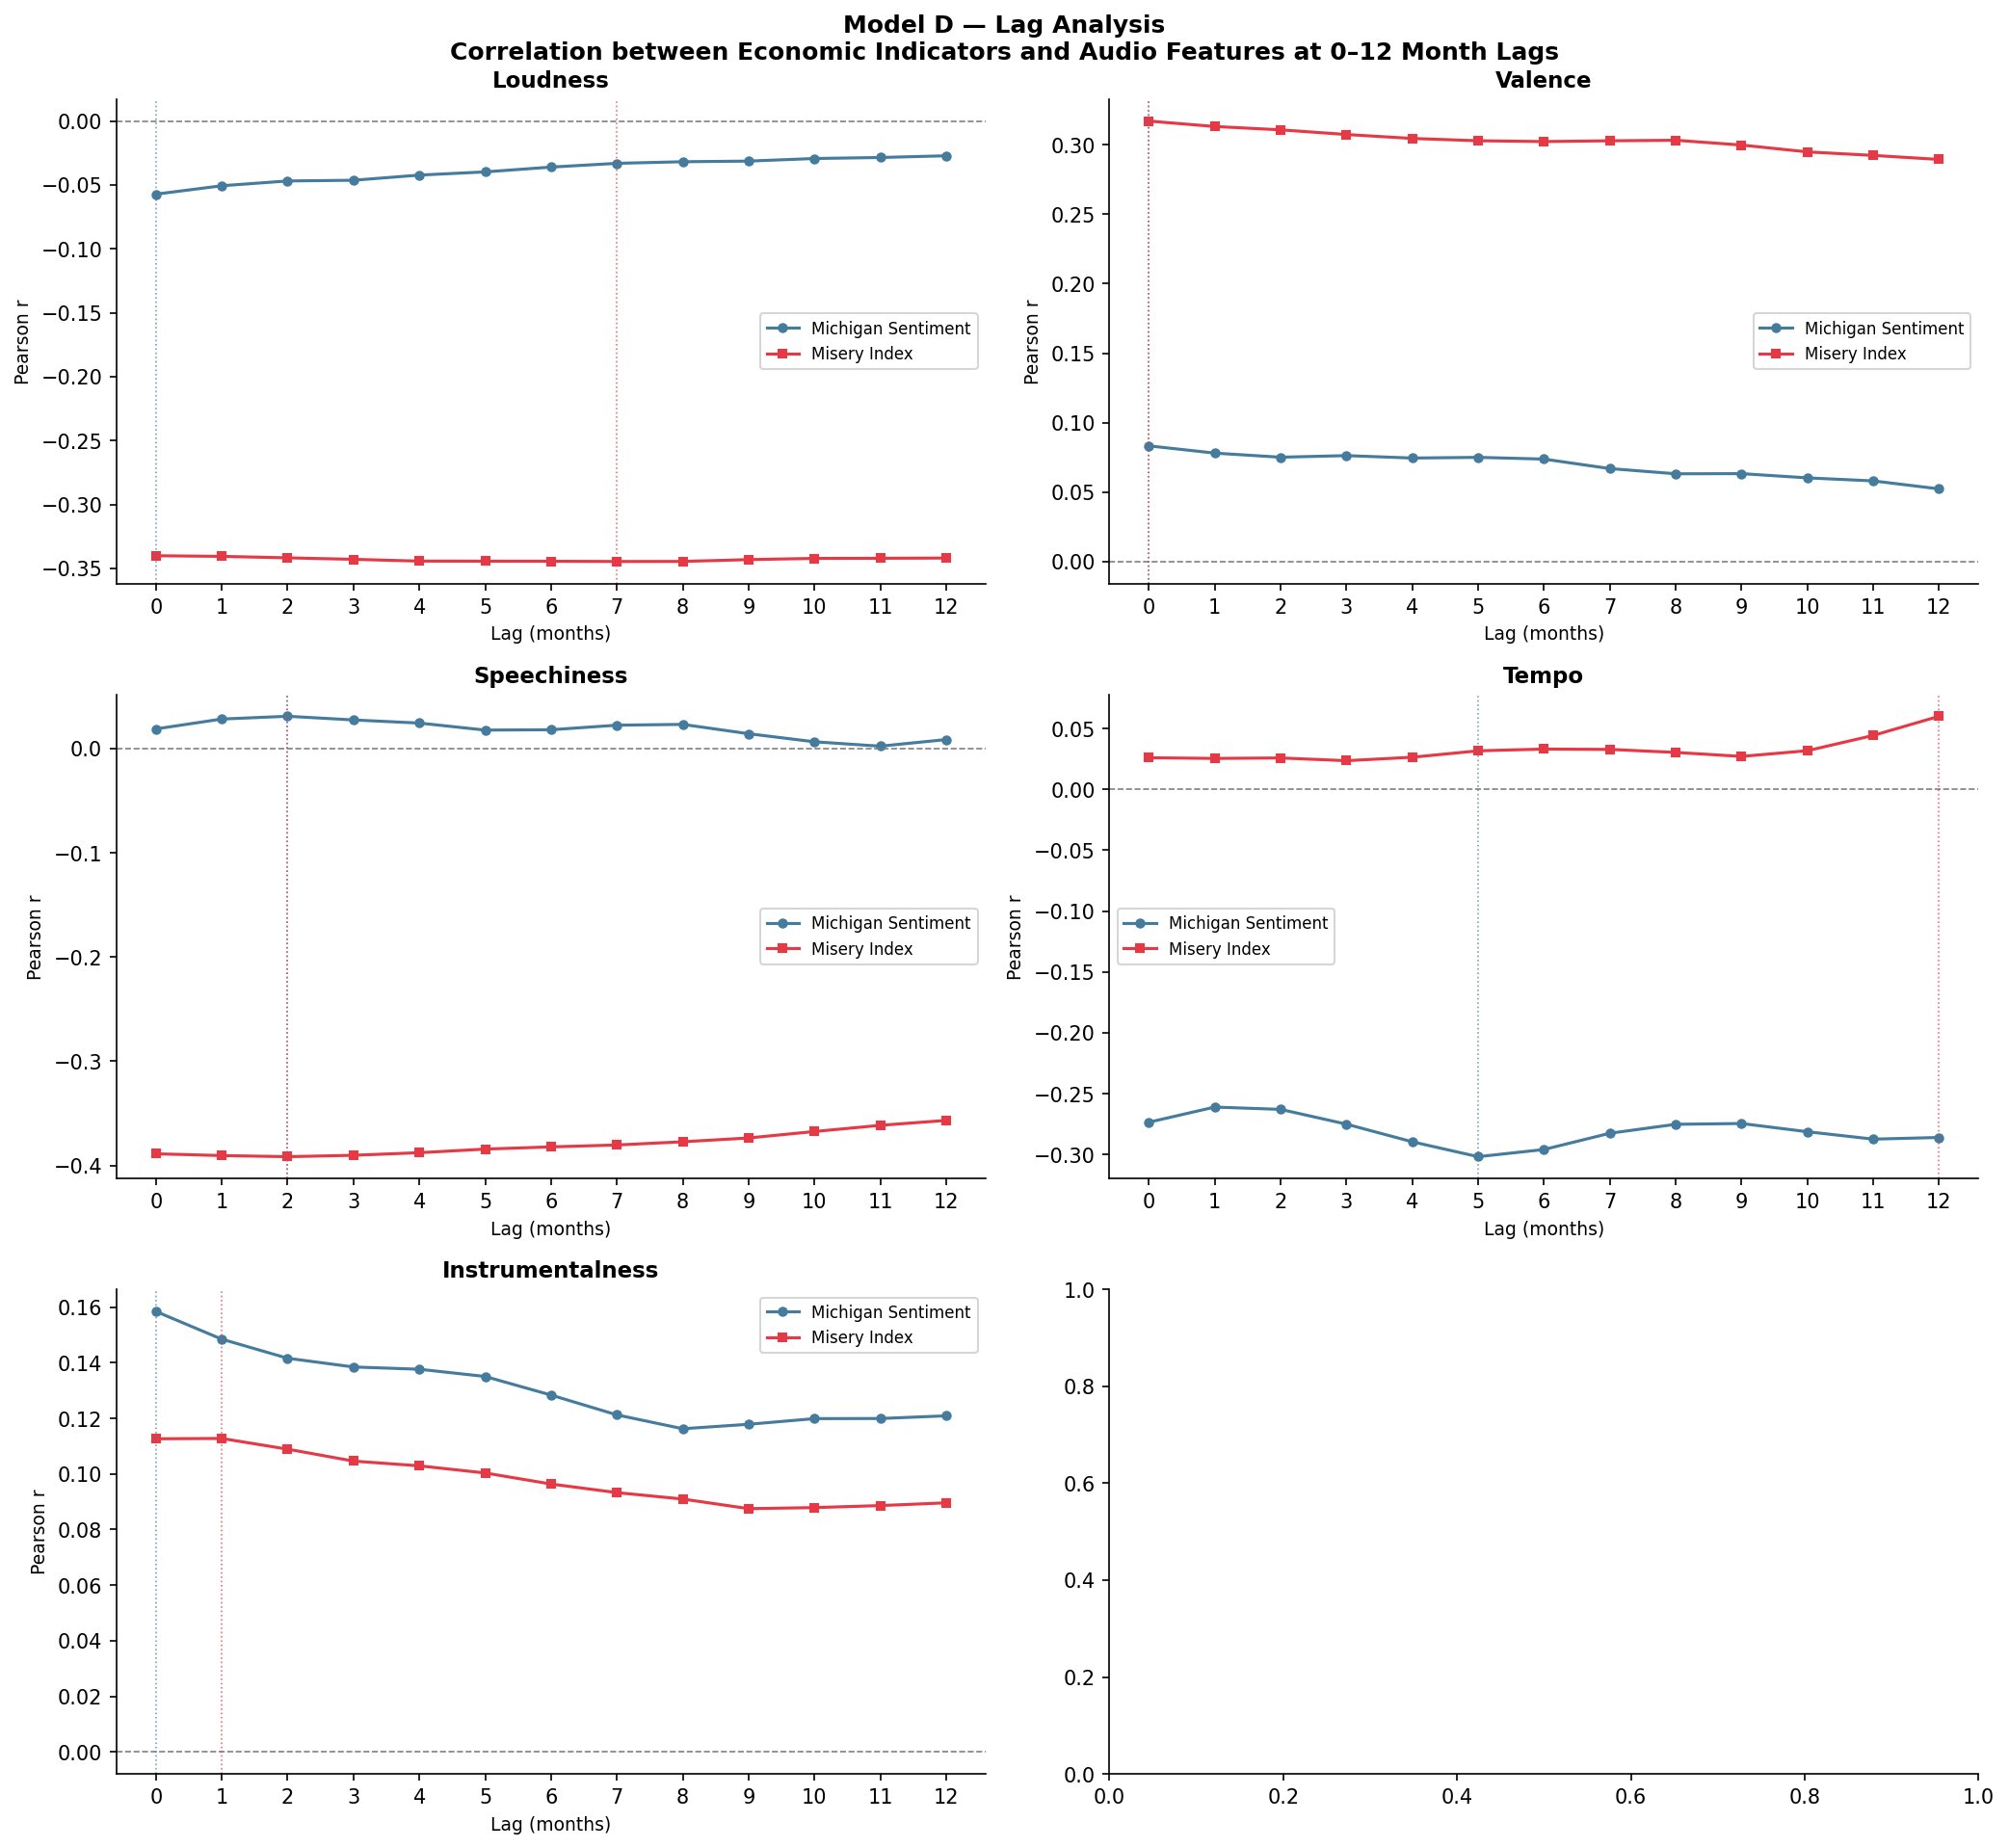

Saved: lag_analysis.png

Peak correlation lags:
Feature           Sentiment peak lag        r    Misery peak lag        r
----------------------------------------------------------------------
loudness                           0   -0.057                  7   -0.345
valence                            0    0.083                  0    0.317
speechiness                        2    0.031                  2   -0.392
tempo                              5   -0.302                 12    0.060
instrumentalness                    0    0.158                  1    0.113


In [14]:
# ── MODEL D: LAG ANALYSIS ─────────────────────────────────────────────────────
LAG_FEATURES = ['loudness', 'valence', 'speechiness', 'tempo', 'instrumentalness']
MAX_LAG = 12

lag_results = {feat: [] for feat in LAG_FEATURES}

df_lag = sent_clean.sort_values('date').copy()

for lag in range(0, MAX_LAG + 1):
    df_lag[f'sentiment_lag{lag}'] = df_lag['michigan_sentiment'].shift(lag)
    df_lag[f'misery_lag{lag}']    = df_lag['misery_index'].shift(lag)

for feat in LAG_FEATURES:
    for lag in range(0, MAX_LAG + 1):
        clean = df_lag[[feat, f'sentiment_lag{lag}', f'misery_lag{lag}']].dropna()
        r_sent, _  = stats.pearsonr(clean[feat], clean[f'sentiment_lag{lag}'])
        r_misery, _ = stats.pearsonr(clean[feat], clean[f'misery_lag{lag}'])
        lag_results[feat].append({
            'lag': lag,
            'r_sentiment': r_sent,
            'r_misery':    r_misery
        })

# Plot lag correlations
fig, axes = plt.subplots(3, 2, figsize=(14, 13), sharey=False)
fig.suptitle(
    'Model D — Lag Analysis\n'
    'Correlation between Economic Indicators and Audio Features at 0–12 Month Lags',
    fontsize=12, fontweight='bold'
)
axes_flat = axes.flatten()

for i, feat in enumerate(LAG_FEATURES):
    ax = axes_flat[i]
    df_plot = pd.DataFrame(lag_results[feat])

    ax.plot(df_plot['lag'], df_plot['r_sentiment'], color='#457B9D',
            marker='o', markersize=4, linewidth=1.5, label='Michigan Sentiment')
    ax.plot(df_plot['lag'], df_plot['r_misery'], color='#E63946',
            marker='s', markersize=4, linewidth=1.5, label='Misery Index')
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')

    # Mark peak correlation lag
    peak_sent  = df_plot.loc[df_plot['r_sentiment'].abs().idxmax()]
    peak_mis   = df_plot.loc[df_plot['r_misery'].abs().idxmax()]
    ax.axvline(peak_sent['lag'], color='#457B9D', linewidth=0.8,
               linestyle=':', alpha=0.7)
    ax.axvline(peak_mis['lag'],  color='#E63946', linewidth=0.8,
               linestyle=':', alpha=0.7)

    ax.set_title(feat.capitalize(), fontsize=11, fontweight='bold')
    ax.set_xlabel('Lag (months)', fontsize=9)
    ax.set_ylabel('Pearson r', fontsize=9)
    ax.set_xticks(range(0, MAX_LAG + 1))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('lag_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lag_analysis.png')

# Print peak lags
print('\nPeak correlation lags:')
print(f'{"Feature":<15} {"Sentiment peak lag":>20} {"r":>8} {"Misery peak lag":>18} {"r":>8}')
print('-' * 70)
for feat in LAG_FEATURES:
    df_plot = pd.DataFrame(lag_results[feat])
    ps = df_plot.loc[df_plot['r_sentiment'].abs().idxmax()]
    pm = df_plot.loc[df_plot['r_misery'].abs().idxmax()]
    print(f'{feat:<15} {int(ps["lag"]):>20} {ps["r_sentiment"]:>8.3f} {int(pm["lag"]):>18} {pm["r_misery"]:>8.3f}')

## Model D — Lag Analysis Summary

The lag analysis reveals that most audio features respond to economic conditions **contemporaneously or within 2 months**, with one notable exception that provides the clearest evidence of a delayed musical response in the entire analysis.

>**Loudness** and **valence** show flat correlation lines across all 12 lags for both predictors — their associations with the Misery Index hold steady at approximately -0.34 and +0.31 respectively from lag 0 through lag 12. These are persistent, real-time relationships. Whatever drives quieter and happier music during economic hardship is a continuous signal, not a delayed one.

>**Speechiness** shows a marginal peak at **lag 2** for the Misery Index (-0.392), slightly stronger than lag 0 (-0.385). This suggests a minor delay of approximately 2 months between changes in economic conditions and their reflection in the vocal density of popular music — consistent with the time it takes for newly recorded music to reach the charts.

>**Instrumentalness** peaks at **lag 0** for Michigan Sentiment (0.158) and **lag 1** for the Misery Index (0.113), confirming a contemporaneous relationship with both predictors.

>**Tempo** is the standout finding. Michigan Sentiment peaks at **lag 5** (-0.302) while the Misery Index never produces a meaningful correlation across any lag (peak r = 0.060 at lag 12). This means tempo takes approximately **5 months** to respond to shifts in consumer confidence — consistent with the music production timeline, where artists writing in response to economic mood produce music that reaches the Billboard charts several months later. This is the strongest evidence in the analysis of a directional, time-delayed relationship between perceived economic conditions and musical character.

**Overall:** the lag analysis supports a largely contemporaneous relationship between economic indicators and audio features, with tempo as the key exception — providing the clearest case for sentiment as a *leading* driver of musical change rather than a coincident one.

---
## Final Summary Table
**Consolidating all model results into one interpretable output.**

In [15]:
# ── FINAL SUMMARY TABLE ───────────────────────────────────────────────────────
summary = df_a[['feature', 'r_squared']].rename(columns={'r_squared': 'R2_ModelA_Misery'})
summary = summary.merge(
    df_b[['feature', 'r_squared']].rename(columns={'r_squared': 'R2_ModelB_Sentiment'}),
    on='feature'
)
summary = summary.merge(
    df_c[['feature', 'r_squared']].rename(columns={'r_squared': 'R2_ModelC_Combined'}),
    on='feature'
)
summary = summary.merge(
    agreement[['feature', 'dominant_ols', 'agree']],
    on='feature'
)
summary = summary.sort_values('R2_ModelC_Combined', ascending=False)

print('Final Summary — All Models')
print('=' * 85)
print(f'{"Feature":<20} {"R²(A) Misery":>14} {"R²(B) Sent":>12} {"R²(C) Both":>12} {"Dominant":>20} {"Robust?":>8}')
print('-' * 85)
for _, row in summary.iterrows():
    print(f"{row['feature']:<20} {row['R2_ModelA_Misery']:>14.4f} "
          f"{row['R2_ModelB_Sentiment']:>12.4f} {row['R2_ModelC_Combined']:>12.4f} "
          f"{row['dominant_ols']:>20} {str(row['agree']):>8}")

print('\nR²(C) > R²(A) and R²(B) confirms that combining both predictors explains more variance.')
print('Dominant = which predictor has the larger absolute coefficient in Model C.')
print('Robust = OLS and Ridge agree on which predictor dominates.')

Final Summary — All Models
Feature                R²(A) Misery   R²(B) Sent   R²(C) Both             Dominant  Robust?
-------------------------------------------------------------------------------------
loudness                     0.1157       0.0033       0.2527         Misery Index     True
valence                      0.1005       0.0069       0.2486         Misery Index     True
speechiness                  0.1511       0.0004       0.2483         Misery Index     True
tempo                        0.0007       0.0748       0.1158         Misery Index    False
instrumentalness             0.0127       0.0251       0.1070         Misery Index    False
energy                       0.0000       0.0198       0.0360         Misery Index    False
acousticness                 0.0065       0.0216       0.0220   Michigan Sentiment     True
mode                         0.0065       0.0000       0.0119         Misery Index     True
liveness                     0.0010       0.0019       0.00

## Final Summary — All Models

The final summary table consolidates R² values across all three OLS models, confirming two consistent patterns across the analysis.

First, combining both predictors (Model C) explains substantially more variance than either alone for the top features — loudness (0.253), valence (0.249), and speechiness (0.248) — confirming that the Misery Index and Michigan Sentiment capture independent, additive information rather than the same underlying signal.

Second, the Robust column identifies which findings can be trusted with confidence. Loudness, valence, and speechiness are the most reliable results in the dataset — both OLS and Ridge agree that the Misery Index is the dominant predictor, and their R² values are the highest across all models. Acousticness and liveness are similarly robust, with Michigan Sentiment confirmed as the dominant predictor by both methods.

For the remaining features — tempo, instrumentalness, energy, and danceability — OLS and Ridge disagree on which predictor dominates, indicating that multicollinearity is distorting the OLS estimates. For these features, the Ridge results should be treated as more reliable than the Model C OLS output.

Overall, Model C consistently outperforms Models A and B in explanatory power across all features, supporting the conclusion that economic hardship and consumer sentiment drive distinct but complementary dimensions of musical taste — and that neither indicator alone tells the full story.

---
## Notebook 3 Summary

**What the four models tell us together:**

- **Model A** replicates Larson (2022) — establishing whether our data confirms her baseline findings on the Misery Index
- **Model B** tests the original hypothesis — whether sentiment is a significant predictor of audio features independent of hard economic data
- **Model C** runs the horse race — when both predictors compete in the same model, which one retains significance?
- **Model D** tests timing — does sentiment lead music shifts by a measurable number of months?
- **Ridge robustness check** — confirms whether the horse race result holds after controlling for multicollinearity between the two predictors